# Dataset analysis

## Loading the data

In [1]:
from datasets import load_dataset

ds = load_dataset("OpenFace-CQUPT/HumanCaption-10M", split="train")
print(f"Length: {len(ds)}")
print(f"Example data point: {ds[0]}")

ds = ds.shuffle(seed=42)

# SMALL DEBUG SUBSET
ds_small = ds.select(range(1500))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

HumanCaption-10M.parquet:   0%|          | 0.00/4.20G [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10388531 [00:00<?, ? examples/s]

Length: 10388531
Example data point: {'image_id': 'split_00009_000171189', 'image': 'split_00009/000171189.jpg', 'human_caption': ['In the image, there are four different pictures showing people and dental-related activities. In one picture, a woman is smiling and holding a toothbrush with her teeth showing. She is wearing heavy makeup, including lipstick, and appears attractive and youthful with a bright smile. Her eyebrows are arched, her nose is large, and she giving her a oval-shaped face. In another picture, a woman is smiling and holding a toothbrush, and a man and a child are also present, likely a family. In the third picture, a woman is smiling and holding dental tools, suggesting she is a dentist or dental hygienist. In the fourth picture, a man and a woman are smiling and posing together, and the woman is holding a toothbrush. Overall, the images depict people engaging in dental care activities, such as brushing their teeth and visiting the dentist.'], 'url': 'http://www.ind

## Cleaning invalid image URLs

In [2]:
from skimage import io
from collections import Counter

valid_indices = []
counter = Counter()

for i in range(len(ds_small)):
    url = ds_small[i]['url']
    try:
        im = io.imread(url)
        counter.update([im.shape])
        valid_indices.append(i)
    except:
        print(f"Invalid image at index {i}: {url}")

proportion_valid_URLs = len(valid_indices) / len(ds_small)
print(f"{proportion_valid_URLs} of the URLs is valid.")

Invalid image at index 0: https://qt.azureedge.net/resources/authors-images-large/nathaniel-hawthorne.jpg
Invalid image at index 3: https://www.costumes-au.com/media/catalog/product/cache/1/thumbnail/280x373/9df78eab33525d08d6e5fb8d27136e95/l/x/lx0158_1.jpg


/usr/local/lib/python3.12/dist-packages/osgeo/gdal.py:312: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


Invalid image at index 14: http://www.blogself.info/t/240x180/40/09/0d/42/40090d428f758c9639f4c1d73a8c38de.jpg
Invalid image at index 20: https://staging.consequenceofsound.net/wp-content/uploads/2020/10/David-Bowie-and-Trent-Reznor.jpg?quality=80&w=807
Invalid image at index 22: https://secureservercdn.net/50.62.172.113/eb8.ef0.myftpupload.com/wp-content/uploads/2017/03/Horizon-Zero-Dawn-15.jpg?time=1597015518
Invalid image at index 29: https://hairstylesideashub.com/wp-content/uploads/2018/08/Long-layered-pixie-over-50.jpg
Invalid image at index 32: https://www.aceshowbiz.com/images/wennpic/preview/diego-boneta-2012-miss-universe-pageant-01.jpg
Invalid image at index 38: http://media.gettyimages.com/photos/lucy-watson-attends-the-uk-premiere-of-man-of-steel-at-odeon-square-picture-id170394197
Invalid image at index 39: https://i2.wp.com/www.lancastercourier.com/wp-content/uploads/2020/01/pelosi-trumpx750-2.jpg?resize=440%2C264&ssl=1
Invalid image at index 41: https://www.JimmyBeansWo

## Creating a cleaned dataset

In [12]:
ds_clean = ds_small.select(valid_indices)
print(len(ds_clean))

953


Show resolutions

687


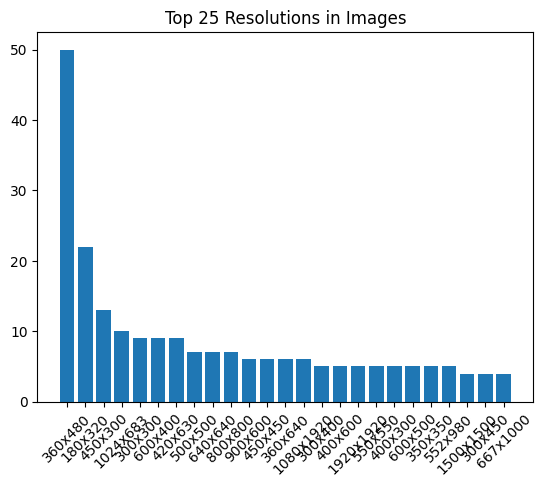

In [ ]:
import matplotlib.pyplot as plt
print(len(counter))
most_common = counter.most_common(25)

resolutions = [f"{w[0]}x{w[1]}" for w, _ in most_common]
counts = [c for _, c in most_common]

plt.figure()
plt.bar(resolutions, counts)
plt.xticks(rotation=45)
plt.title(f"Top {25} Resolutions in Images")
plt.show()

## Tokenize captions

In [ ]:
import re
import matplotlib.pyplot as plt
import numpy as np

def tokenize(text):
  text = text.lower()
  text = re.sub(r"[^a-z\s]", "", text) # I did it without numbers for now because I need only words for attributes
  return text.split()

## Length distribution

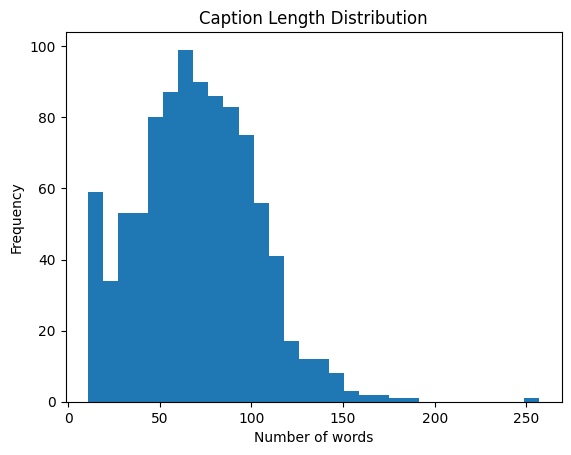

In [ ]:
lengths = []

for i in range(len(ds_clean)):
    caption = ds_clean[i]["human_caption"]
    tokens = tokenize(caption[0])
    lengths.append(len(tokens))

plt.figure()
plt.hist(lengths, bins=30)
plt.title("Caption Length Distribution")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

## Keyword frequency analysis

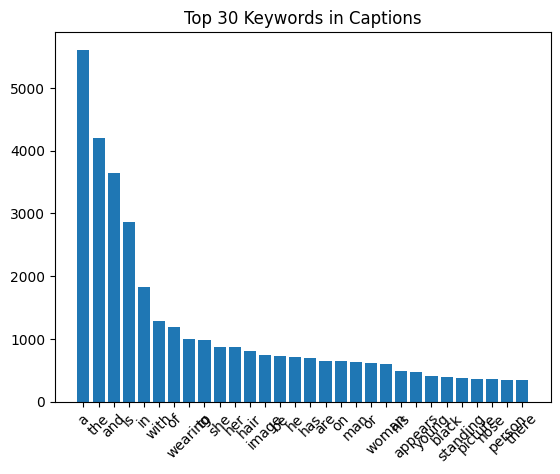

In [ ]:
from collections import Counter

NUM_TOP_WORDS = 30
counter = Counter()

for i in range(len(ds_clean)):
    caption = ds_clean[i]["human_caption"]
    tokens = tokenize(caption[0])
    counter.update(tokens)

# Top ... words
most_common = counter.most_common(NUM_TOP_WORDS)

words = [w for w, _ in most_common]
counts = [c for _, c in most_common]

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title(f"Top {NUM_TOP_WORDS} Keywords in Captions")
plt.show()

## Attribute extraction

In [ ]:
attributes = {
    "male": ["male", "man", "boy", "guy"],
    "female": ["female", "woman", "girl", "lady"],
    "young": ["young", "child", "teen", "baby"],
    "old": ["old", "elderly"],
    "white": ["white", "caucasian"],
    "black": ["black", "african american"],
    "asian": ["asian"],
    "nudity": ["naked", "nude", "breasts", "topless", "bottomless"]
}

In [ ]:
def extract_attributes(tokens):
    found = set()

    for attr, keywords in attributes.items():
        for kw in keywords:
            if kw in tokens:
                found.add(attr)

    return found

In [ ]:
attr_list = list(attributes.keys())
index = {a: i for i, a in enumerate(attr_list)}

matrix = np.zeros((len(attr_list), len(attr_list)))

for i in range(len(ds_clean)):
    caption = ds_clean[i]["human_caption"]
    tokens = tokenize(caption[0])
    attrs = list(extract_attributes(tokens))

    for a1 in attrs:
        for a2 in attrs:
            matrix[index[a1]][index[a2]] += 1

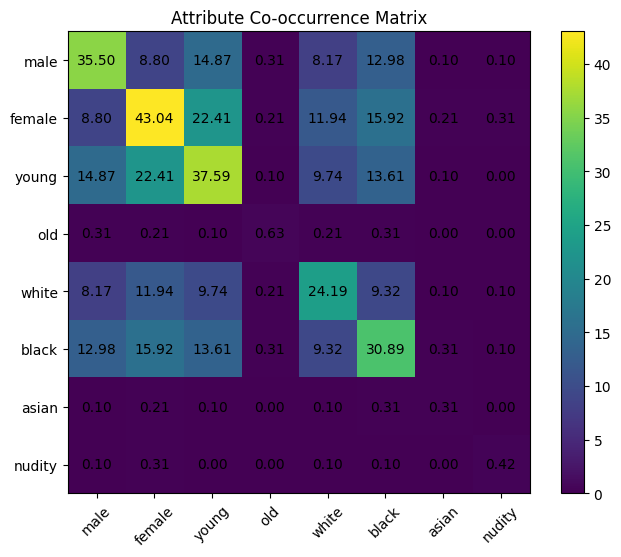

In [ ]:
for i in matrix:
    for j in range(len(i)):
      i[j] = i[j]/9.55


plt.figure(figsize=(8, 6))
plt.imshow(matrix)
plt.colorbar()

plt.xticks(range(len(attr_list)), attr_list, rotation=45)
plt.yticks(range(len(attr_list)), attr_list)

for i in range(len(matrix)):
    for j in range(len(matrix)):
        plt.text(j, i, f"{(matrix[i,j]):.2f}", ha="center", va="center")

plt.title("Attribute Co-occurrence Matrix")
plt.show()

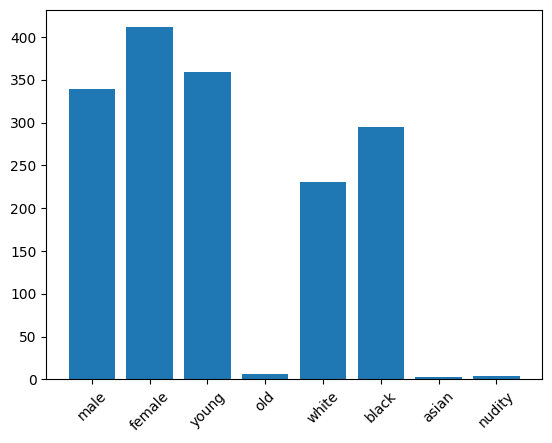

In [ ]:
counts = {a: 0 for a in attributes}

for i in range(len(ds_clean)):
    tokens = tokenize(ds_clean[i]["human_caption"][0])
    found = extract_attributes(tokens)
    for a in found:
        counts[a] += 1

plt.bar(counts.keys(), counts.values())
plt.xticks(rotation=45)
plt.show()

## One dimensional visualization
I used similar code to: https://medium.com/thedeephub/understanding-pca-visualization-with-pytorch-3a21f533d0dc

In [ ]:
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-otgk76sr
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-otgk76sr
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.6 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=be6a41009e1af429bc9659733c9f4a18cbbf328cdaea6a9b0741846745f780fd
  Stored in directory: /tmp/pip-ephem-wheel-cache-v22h332p/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


100%|███████████████████████████████████████| 338M/338M [00:05<00:00, 67.1MiB/s]


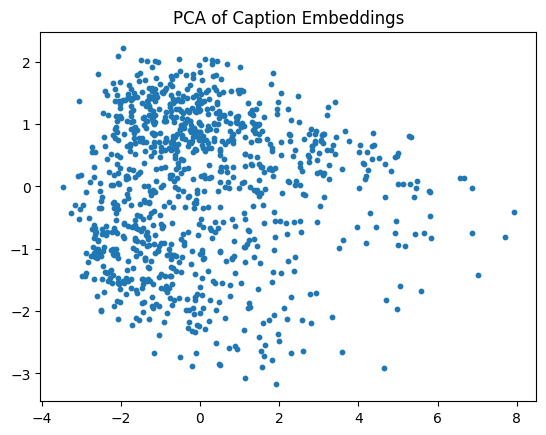

In [ ]:
import torch
import clip
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
model, _ = clip.load("ViT-B/32", device=device)

texts = [ds_clean[i]["human_caption"][0] for i in range(len(ds_clean))]

with torch.no_grad():
    tokens = clip.tokenize(texts, context_length=77, truncate=True).to(device)
    emb = model.encode_text(tokens).cpu().numpy()

pca = PCA(n_components=3)
reduced = pca.fit_transform(emb)

plt.scatter(reduced[:,0], reduced[:,1], s=10)
plt.title("PCA of Caption Embeddings")
plt.show()

Pixel Intensity


In [ ]:
import cv2, matplotlib.pyplot as plt
def plot_gray_hist(im):
    # Grayscale Histogram
    g = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
    plt.subplot(122), plt.hist(g.ravel(),256,[0,256],color='k'), plt.title("Gray Histogram")
    plt.show()

/tmp/ipykernel_28117/2398156893.py:5: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(122), plt.hist(g.ravel(),256,[0,256],color='k'), plt.title("Gray Histogram")


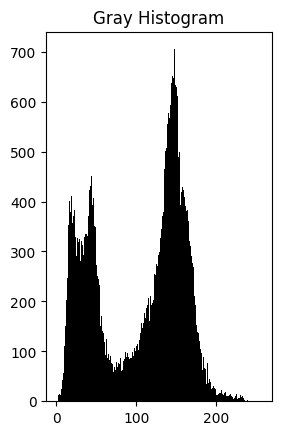

/tmp/ipykernel_28117/2398156893.py:5: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(122), plt.hist(g.ravel(),256,[0,256],color='k'), plt.title("Gray Histogram")


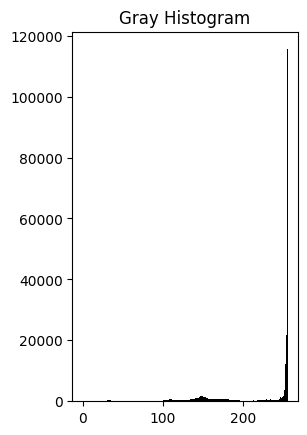

/tmp/ipykernel_28117/2398156893.py:5: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(122), plt.hist(g.ravel(),256,[0,256],color='k'), plt.title("Gray Histogram")


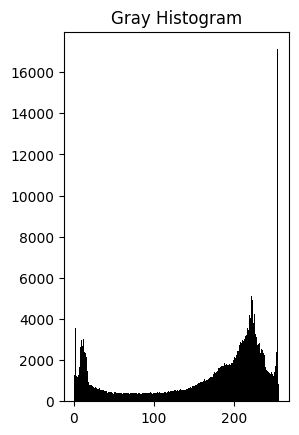

/tmp/ipykernel_28117/2398156893.py:5: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(122), plt.hist(g.ravel(),256,[0,256],color='k'), plt.title("Gray Histogram")


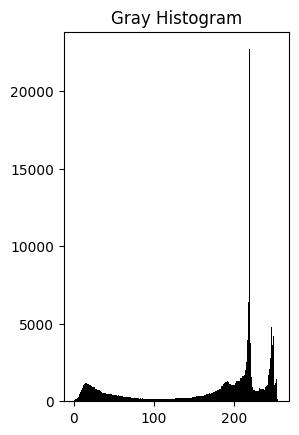

/tmp/ipykernel_28117/2398156893.py:5: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(122), plt.hist(g.ravel(),256,[0,256],color='k'), plt.title("Gray Histogram")


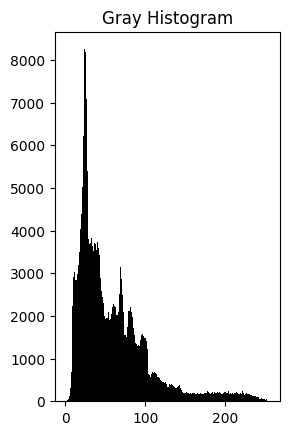

/tmp/ipykernel_28117/2398156893.py:5: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(122), plt.hist(g.ravel(),256,[0,256],color='k'), plt.title("Gray Histogram")


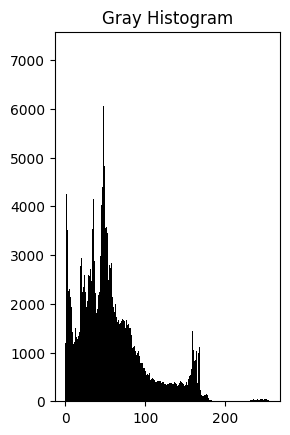

/tmp/ipykernel_28117/2398156893.py:5: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(122), plt.hist(g.ravel(),256,[0,256],color='k'), plt.title("Gray Histogram")


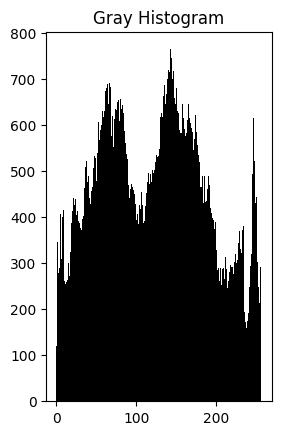

/tmp/ipykernel_28117/2398156893.py:5: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(122), plt.hist(g.ravel(),256,[0,256],color='k'), plt.title("Gray Histogram")


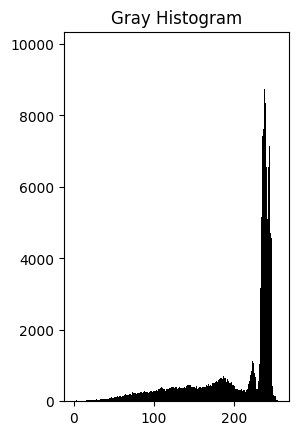

/tmp/ipykernel_28117/2398156893.py:5: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(122), plt.hist(g.ravel(),256,[0,256],color='k'), plt.title("Gray Histogram")


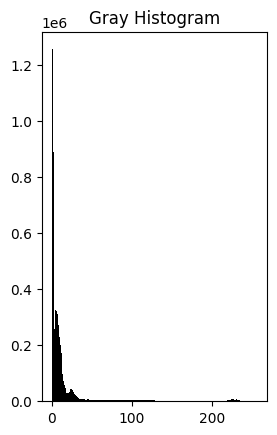

/tmp/ipykernel_28117/2398156893.py:5: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(122), plt.hist(g.ravel(),256,[0,256],color='k'), plt.title("Gray Histogram")


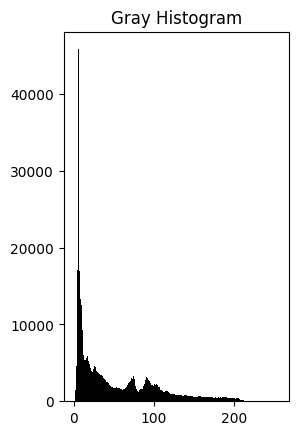

/tmp/ipykernel_28117/2398156893.py:5: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(122), plt.hist(g.ravel(),256,[0,256],color='k'), plt.title("Gray Histogram")


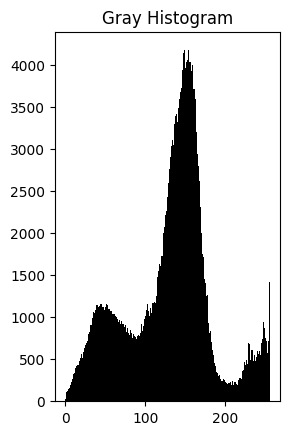

/tmp/ipykernel_28117/2398156893.py:5: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(122), plt.hist(g.ravel(),256,[0,256],color='k'), plt.title("Gray Histogram")


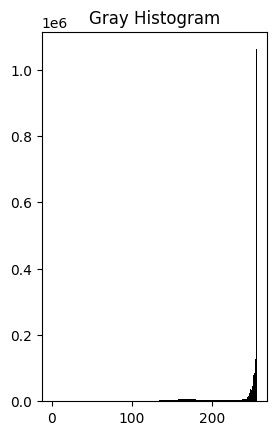

/tmp/ipykernel_28117/2398156893.py:5: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(122), plt.hist(g.ravel(),256,[0,256],color='k'), plt.title("Gray Histogram")


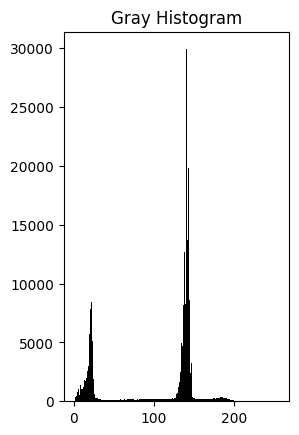

/tmp/ipykernel_28117/2398156893.py:5: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(122), plt.hist(g.ravel(),256,[0,256],color='k'), plt.title("Gray Histogram")


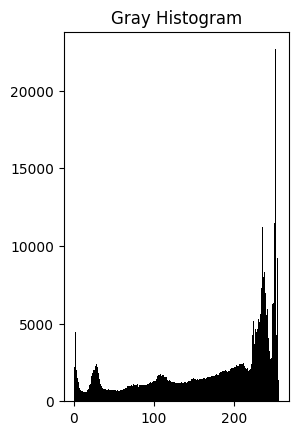

/tmp/ipykernel_28117/2398156893.py:5: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(122), plt.hist(g.ravel(),256,[0,256],color='k'), plt.title("Gray Histogram")


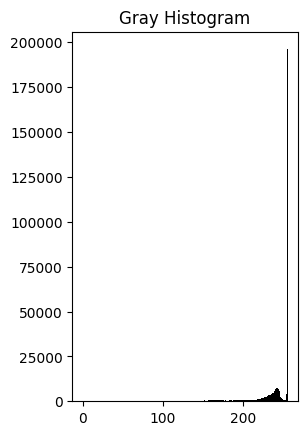

/tmp/ipykernel_28117/2398156893.py:5: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(122), plt.hist(g.ravel(),256,[0,256],color='k'), plt.title("Gray Histogram")


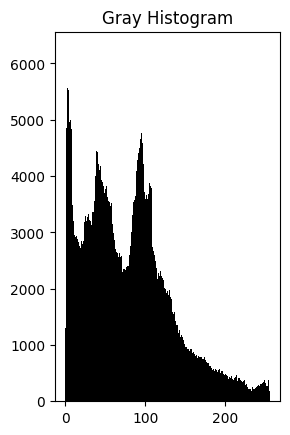

/tmp/ipykernel_28117/2398156893.py:5: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(122), plt.hist(g.ravel(),256,[0,256],color='k'), plt.title("Gray Histogram")


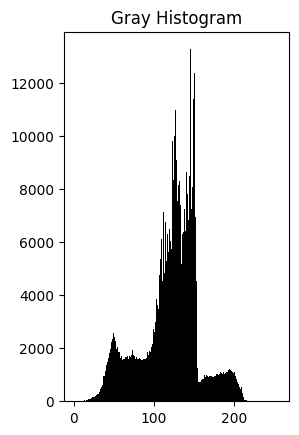

/tmp/ipykernel_28117/2398156893.py:5: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(122), plt.hist(g.ravel(),256,[0,256],color='k'), plt.title("Gray Histogram")


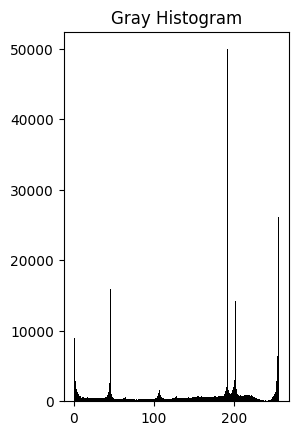

/tmp/ipykernel_28117/2398156893.py:5: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(122), plt.hist(g.ravel(),256,[0,256],color='k'), plt.title("Gray Histogram")


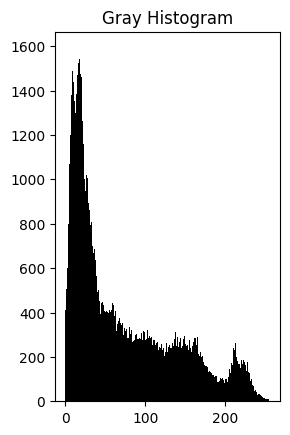

/tmp/ipykernel_28117/2398156893.py:5: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(122), plt.hist(g.ravel(),256,[0,256],color='k'), plt.title("Gray Histogram")


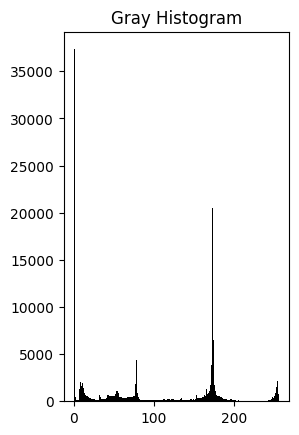

In [ ]:
#show the first 20 histograms
for i in range(20):
    url = ds_clean[i]["url"]
    img = io.imread(url)
    plot_gray_hist(img)

## CLIP Score

In [7]:
!pip install transformers tqdm scikit-image

In [8]:
import torch
from transformers import CLIPProcessor, CLIPModel

device = "cuda" if torch.cuda.is_available() else "cpu"

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

model.eval()

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

In [9]:
import torch.nn.functional as F

def clip_score(image, text):
  # Prepare inputs: convert image and text into tensors, tokenize text, resize image
    inputs = processor(
        text=[text],
        images=image,
        return_tensors="pt",
        padding=True,
        truncation=True).to(device)

    with torch.no_grad(): # turns of gradient tracking
        # Run the CLIP model
        outputs = model(**inputs)

        # Extract embeddings
        image_embeddings = outputs.image_embeds
        text_embeddings = outputs.text_embeds

        # Normalize embeddings
        image_embeddings = F.normalize(image_embeddings, dim=-1)
        text_embeddings = F.normalize(text_embeddings, dim=-1)

        # Compute similarity between image and text
        similarity = image_embeddings @ text_embeddings.T

        score = similarity.item()

    final_score = max(score, 0) * 100

    return final_score

  4%|▍         | 37/953 [00:49<07:25,  2.05it/s]

Error at 36: Unable to infer channel dimension format


  9%|▉         | 85/953 [01:16<07:40,  1.89it/s]

Error at 84: Unable to infer channel dimension format


 10%|█         | 98/953 [01:23<07:54,  1.80it/s]

...

Error at 920: Unable to infer channel dimension format


 97%|█████████▋| 929/953 [13:33<24:45, 61.88s/it]

Error at 928: <urlopen error [Errno 104] Connection reset by peer>


100%|██████████| 953/953 [13:47<00:00,  1.15it/s]


Average CLIPScore: 28.570852615545938
Median CLIPScore: 29.49318289756775
Standard deviation: 6.638916985248082


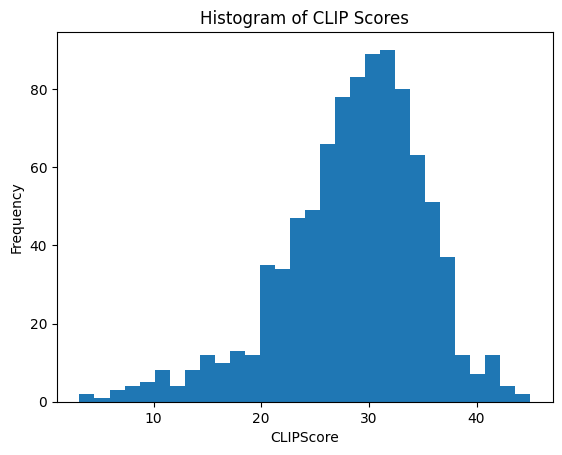

In [13]:
from skimage import io
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

scores = []

for i in tqdm(range(len(ds_clean))):
    try:
        url = ds_clean[i]["url"]
        text = ds_clean[i]["human_caption"][0]

        image = io.imread(url)

        score = clip_score(image, text)
        scores.append(score)

    except Exception as e:
        print(f"Error at {i}: {e}")

print("Average CLIPScore:", np.mean(scores))
print("Median CLIPScore:", np.median(scores))
print("Standard deviation:", np.std(scores))

# Histogram
plt.figure()
plt.hist(scores, bins=30)
plt.xlabel("CLIPScore")
plt.ylabel("Frequency")
plt.title("Histogram of CLIP Scores")
plt.show()